<a href="https://colab.research.google.com/github/shllangermann/dsrp-repo/blob/main/DSRP_2026_langermann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSRP 2026 - NYT Best Sellers
Research Question: How does an author's presence on the bestseller list vary by total weeks?

**Setup**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
bestsell_df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-05-10/nyt_titles.tsv', sep='\t')
bestsell_df.head()

,id,title,author,year,total_weeks,first_week,debut_rank,best_rank
0,0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,1991-05-05,1,2
1,1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,1992-04-26,14,2
2,10,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,1990-05-06,4,8
3,100,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,2012-05-27,3,14
4,1000,CHANGING FACES,Kimberla Lawson Roby,2006,1,2006-02-19,11,14


**EDA**

In [ ]:
bestsell_df.info()
# 4 null values in "author"
# PROBLEM: authors are in the wrong column
bestsell_df[bestsell_df['author'].isnull()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7431 entries, 0 to 7430
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        7431 non-null   object
 1   author       7428 non-null   object
 2   year         7431 non-null   int64 
 3   total_weeks  7431 non-null   int64 
 4   first_week   7431 non-null   object
 5   debut_rank   7431 non-null   int64 
 6   best_rank    7431 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 406.5+ KB


,title,author,year,total_weeks,first_week,debut_rank,best_rank
1360,"HOLY DEADLOCK, by A. P. Herbert. (Doubleday, ...",NaN,1934,4,1934-08-13,5,4
2374,"MUTINY ON THE BOUNTY, Charles Nordhoff and Jam...",NaN,1932,2,1932-11-14,2,2
6556,"A CITY OF BELLS, by Elizabeth Goudge. (Coward...",NaN,1937,3,1937-06-21,7,6


In [ ]:
bestsell_df = bestsell_df.drop_duplicates()
bestsell_df

,title,author,year,total_weeks,first_week,debut_rank,best_rank
0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,1991-05-05,1,2
1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,1992-04-26,14,2
2,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,1990-05-06,4,8
3,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,2012-05-27,3,14
4,CHANGING FACES,Kimberla Lawson Roby,2006,1,2006-02-19,11,14
...,...,...,...,...,...,...,...
7426,CHANCES,Jackie Collins,1981,1,1981-10-04,1,15
7427,CHANCES ARE ...,Richard Russo,2019,3,2019-08-18,5,8
7428,CHANGE OF HEART,Jodi Picoult,2008,8,2008-03-23,9,1
7429,CHANGES,Danielle Steel,1983,28,1983-09-11,12,2


In [ ]:
bestsell_df['title'] = bestsell_df['title'].replace({'EAST AND WEST, by Somerset Maugham. (Doubleday, Doran.)':'EAST AND WEST', 'HOLY DEADLOCK, by A. P. Herbert. (Doubleday, Doran.)':'HOLY DEADLOCK', 'MUTINY ON THE BOUNTY, Charles Nordhoff and James N. Hall. (Little, Brown.)':'MUTINY ON THE BOUNTY', 'A CITY OF BELLS, by Elizabeth Goudge. (Coward-McCann.)':'A CITY OF BELLS'})
bestsell_df

,title,author,year,total_weeks,first_week,debut_rank,best_rank
0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,1991-05-05,1,2
1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,1992-04-26,14,2
2,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,1990-05-06,4,8
3,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,2012-05-27,3,14
4,CHANGING FACES,Kimberla Lawson Roby,2006,1,2006-02-19,11,14
...,...,...,...,...,...,...,...
7426,CHANCES,Jackie Collins,1981,1,1981-10-04,1,15
7427,CHANCES ARE ...,Richard Russo,2019,3,2019-08-18,5,8
7428,CHANGE OF HEART,Jodi Picoult,2008,8,2008-03-23,9,1
7429,CHANGES,Danielle Steel,1983,28,1983-09-11,12,2


In [ ]:
# fill null values

bestsell_df.loc[661] = bestsell_df.loc[661].fillna('Somerset Maugham')
bestsell_df.loc[1360] = bestsell_df.loc[1360].fillna('A. P. Herbert')
bestsell_df.loc[2374] = bestsell_df.loc[2374].fillna('Charles Nordhoff')
bestsell_df.loc[6556] = bestsell_df.loc[6556].fillna('Elizabeth Goudge')

In [ ]:
bestsell_df = bestsell_df.drop(columns = ['id'])

EDA Question 1 - Who are the top 5 authors on the best sellers list?

In [ ]:
# top 5 list
top_authors = bestsell_df['author'].value_counts().nlargest(5).index
top_authors

Index(['Danielle Steel', 'Stuart Woods', 'Stephen King', 'Robert B. Parker',
       'John Sandford'],
      dtype='object', name='author')

EDA Question 2 - Of the top 5, who has the most books on the list?

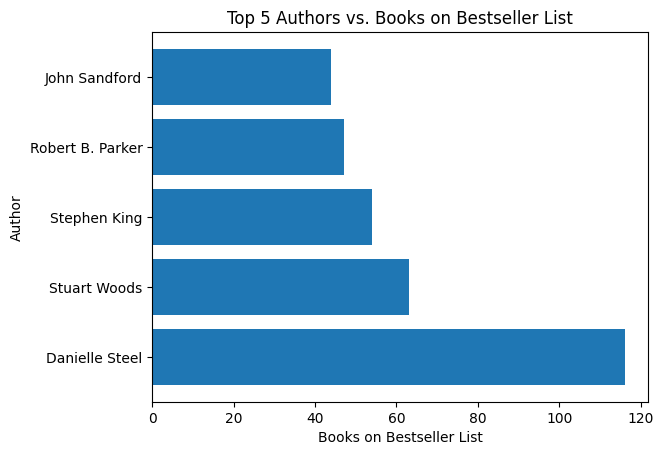

In [ ]:
# danielle steel has the most books on the bestseller list
filtered_data = bestsell_df[bestsell_df['author'].isin(top_authors)]
bars = filtered_data['author'].value_counts()

plt.barh(bars.index, bars)

plt.ylabel('Author')
plt.xlabel('Books on Bestseller List')
plt.title('Top 5 Authors vs. Books on Bestseller List')

plt.show()


EDA Question 3 - Which author, of all the authors in the dataset (concentrated to top 5 because it'll still be accurate), has the highest total of weeks on the list?

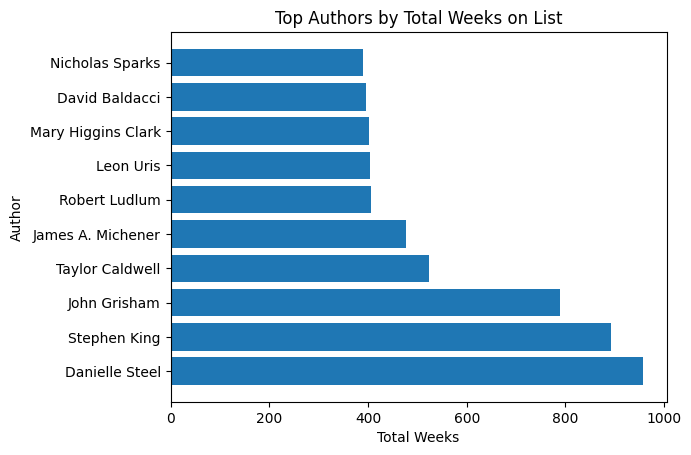

In [ ]:
# ans: yet again danielle steel. noticing a pattern

top_authors = bestsell_df.groupby('author')['total_weeks'].sum().nlargest(10)

plt.barh(top_authors.index, top_authors.values)
plt.ylabel('Author')
plt.xlabel('Total Weeks')
plt.title('Top Authors by Total Weeks on List')

plt.show()

EDA Question 3 - Which decade saw the most bestsellers published?

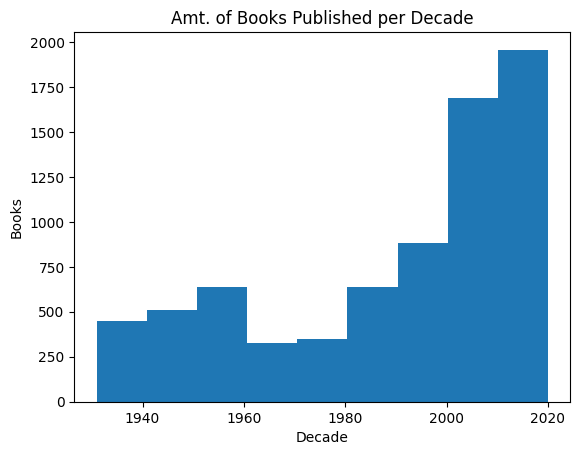

In [ ]:
# ans: 2010 - 2020

plt.hist(bestsell_df["year"], bins= 9)

plt.title("Amt. of Books Published per Decade")
plt.xlabel("Decade")
plt.ylabel("Books")
plt.show()